# Ames Housing — Notebook 2 

> **Objectif** : Améliorer le score Kaggle obtenu avec ElasticNet (Notebook 1) en utilisant des modèles plus puissants et un tuning intelligent des hyperparamètres.

On ne refait pas l'EDA — elle est déjà faite dans le Notebook 1. On repart du preprocessing et on va droit au but.

---

## 1. Chargement & Preprocessing

On reproduit exactement les mêmes étapes que dans le Notebook 1 — même nettoyage, même feature engineering, même pipeline. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chargement
df_train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df_test  = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

# ── Valeurs manquantes catégorielles → 'None'
cols_fillna = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType','Electrical',
               'KitchenQual','SaleType','Functional','Exterior2nd','Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning','Utilities']
for col in cols_fillna:
    df_train[col] = df_train[col].fillna('None')
    df_test[col]  = df_test[col].fillna('None')

# ── Valeurs manquantes numériques → moyenne
means = df_train.mean(numeric_only=True)
for col in means.index:
    df_train[col] = df_train[col].fillna(means[col])

# ── Transformation log de la cible
df_train['log_SalePrice'] = np.log1p(df_train['SalePrice'])

# ── Suppression Id
df_train = df_train.drop(columns=['Id'])

# ── Suppression des 2 outliers extrêmes
mask = ~((df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300_000))
df_clean = df_train[mask].copy()

# ── Feature Engineering
df_clean['HouseAge']        = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['YearsSinceRemod'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalSF']         = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']
df_clean['TotalBath']       = (df_clean['FullBath'] + 0.5*df_clean['HalfBath']
                               + df_clean['BsmtFullBath'] + 0.5*df_clean['BsmtHalfBath'])
df_clean['HasPool']         = (df_clean['PoolArea'] > 0).astype(int)
df_clean['HasGarage']       = (df_clean['GarageArea'] > 0).astype(int)
df_clean['Has2ndFloor']     = (df_clean['2ndFlrSF'] > 0).astype(int)
df_clean['HasBsmt']         = (df_clean['TotalBsmtSF'] > 0).astype(int)

# ── Séparation features / cible
y = df_clean['log_SalePrice'].copy()
cols_to_drop = ['SalePrice','log_SalePrice','GarageArea','1stFlrSF',
                'TotRmsAbvGrd','Street','Utilities']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
X = df_clean.drop(columns=cols_to_drop)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# ── Pipeline preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# ── Split 80/20
y_deciles = pd.qcut(y, q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_deciles
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Preprocessing terminé")
print(f"   X_train : {X_train.shape} | X_test : {X_test.shape}")


Preprocessing terminé
   X_train : (1166, 82) | X_test : (292, 82)


En une seule cellule, on a reproduit tout le travail de nettoyage du Notebook 1. Les données sont propres, les nouvelles features sont créées, et le pipeline est prêt. 

---
## 2. XGBoost


In [2]:
from xgboost import XGBRegressor

# ── Définition du modèle XGBoost dans un pipeline complet
xgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = 0
    ))
])

# ── Validation croisée 5-Fold
xgb_scores = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_rmse_cv = -xgb_scores.mean()
xgb_rmse_std = xgb_scores.std()

print(f"XGBoost — RMSE CV : {xgb_rmse_cv:.5f} (± {xgb_rmse_std:.5f})")

# ── Entraînement final et évaluation sur le test set
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb  = xgb_pipeline.predict(X_test)
xgb_rmse    = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2      = r2_score(y_test, y_pred_xgb)
xgb_mape    = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_xgb)) / np.expm1(y_test))) * 100

print(f"XGBoost — RMSE Test : {xgb_rmse:.5f} | R² : {xgb_r2:.4f} | MAPE : {xgb_mape:.2f}%")


XGBoost — RMSE CV : 0.12364 (± 0.01155)
XGBoost — RMSE Test : 0.11439 | R² : 0.9220 | MAPE : 8.20%


---
## 3. LightGBM

La différence principale avec XGBoost : LightGBM fait croître ses arbres **par feuille** (leaf-wise) plutôt que **par niveau** (level-wise). Concrètement, il va creuser là où l'erreur est la plus grande, ce qui le rend très efficace mais aussi plus sensible à l'overfitting si on ne le contrôle pas.

In [3]:
from lightgbm import LGBMRegressor

# ── Définition du modèle LightGBM
lgbm_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LGBMRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = -1
    ))
])

# ── Validation croisée 5-Fold
lgbm_scores = cross_val_score(
    lgbm_pipeline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lgbm_rmse_cv  = -lgbm_scores.mean()
lgbm_rmse_std = lgbm_scores.std()

print(f"LightGBM — RMSE CV : {lgbm_rmse_cv:.5f} (± {lgbm_rmse_std:.5f})")

# ── Entraînement final
lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
lgbm_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
lgbm_r2     = r2_score(y_test, y_pred_lgbm)
lgbm_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_lgbm)) / np.expm1(y_test))) * 100

print(f"LightGBM — RMSE Test : {lgbm_rmse:.5f} | R² : {lgbm_r2:.4f} | MAPE : {lgbm_mape:.2f}%")


LightGBM — RMSE CV : 0.12903 (± 0.00882)
LightGBM — RMSE Test : 0.11574 | R² : 0.9201 | MAPE : 8.14%


On a entraîné LightGBM avec exactement les mêmes paramètres de départ que XGBoost — c'est volontaire, pour comparer les deux à "armes égales" avant le tuning. Si LightGBM est déjà meilleur avec les mêmes réglages, ça confirme qu'il exploite mieux la structure de nos données.

---
## 4. Tuning avec Optuna

Jusqu'ici on a utilisé des hyperparamètres "raisonnables" mais pas optimaux. Optuna va les trouver automatiquement.

Comment ça fonctionne ? Au lieu de tester toutes les combinaisons possibles comme le fait Grid Search (ce qui prendrait des heures), Optuna est **intelligent** : il observe quels paramètres donnent de bons résultats et explore davantage dans ces directions. C'est comme un chercheur qui affine ses hypothèses au fur et à mesure de ses expériences plutôt que de tout tester dans le désordre.

On va tuner **LightGBM**, généralement le plus rapide à optimiser.

In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Preprocessing appliqué une seule fois pour accélérer Optuna
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

def objective(trial):
    """Optuna appelle cette fonction à chaque essai avec de nouveaux hyperparamètres."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state'    : 42,
        'verbosity'       : -1,
        'n_jobs'          : -1
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

# ── Lancement de l'optimisation (50 essais)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Meilleurs hyperparamètres trouvés :")
for k, v in study.best_params.items():
    print(f"   {k} : {v}")
print(f"\n   RMSE CV optimisée : {study.best_value:.5f}")


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs hyperparamètres trouvés :
   n_estimators : 675
   learning_rate : 0.03686536492487187
   max_depth : 3
   num_leaves : 61
   subsample : 0.6780045432517744
   colsample_bytree : 0.7984929175055939
   min_child_samples : 11
   reg_alpha : 0.0004076558904067308
   reg_lambda : 0.0035114131578023503

   RMSE CV optimisée : 0.12495


LightGBM Optuna — RMSE Test : 0.11388 | R² : 0.9227 | MAPE : 8.28%


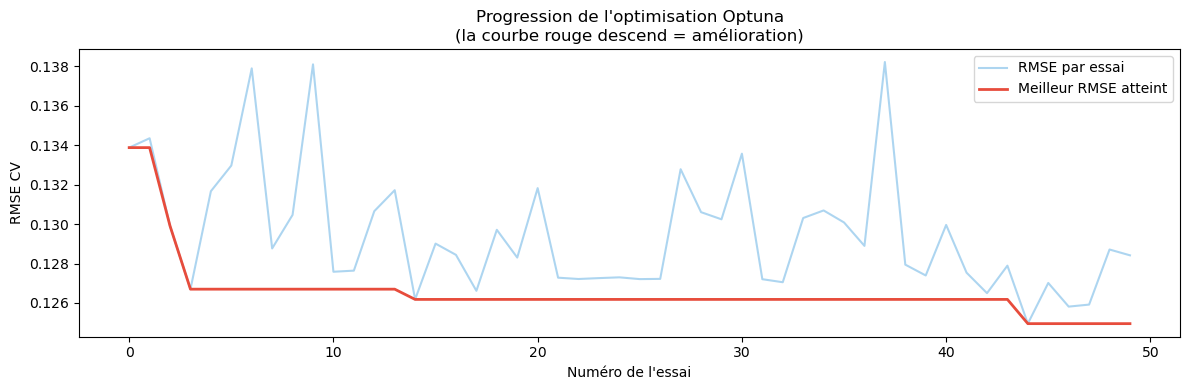

In [5]:
# ── Entraînement du modèle optimisé avec les meilleurs paramètres
best_lgbm = LGBMRegressor(**study.best_params, random_state=42, verbosity=-1, n_jobs=-1)
best_lgbm.fit(X_train_prep, y_train)

y_pred_optuna = best_lgbm.predict(X_test_prep)
optuna_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
optuna_r2     = r2_score(y_test, y_pred_optuna)
optuna_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_optuna)) / np.expm1(y_test))) * 100

print(f"LightGBM Optuna — RMSE Test : {optuna_rmse:.5f} | R² : {optuna_r2:.4f} | MAPE : {optuna_mape:.2f}%")

# ── Visualisation de la progression d'Optuna
trial_values = [t.value for t in study.trials]
plt.figure(figsize=(12, 4))
plt.plot(trial_values, alpha=0.4, color='#3498db', label='RMSE par essai')
plt.plot(pd.Series(trial_values).cummin(), color='#e74c3c', linewidth=2, label='Meilleur RMSE atteint')
plt.xlabel('Numéro de l\'essai')
plt.ylabel('RMSE CV')
plt.title('Progression de l\'optimisation Optuna\n(la courbe rouge descend = amélioration)')
plt.legend()
plt.tight_layout()
plt.show()


---
## 5. Stacking — Combiner les modèles

Le stacking est une technique simple mais puissante : plutôt que de choisir "le meilleur modèle", on les fait tous travailler ensemble. Chaque modèle apporte son regard particulier sur les données, et un méta-modèle final (ici Ridge) apprend à combiner leurs prédictions de façon optimale.

C'est un peu comme demander l'avis de plusieurs experts immobiliers et faire une synthèse pondérée de leurs estimations plutôt que de n'en écouter qu'un seul.

In [6]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── On définit les modèles de base (les "experts")
# Chacun est un pipeline complet avec son propre preprocessing
estimators = [
    ('elasticnet', Pipeline([
        ('prep',  preprocessor),
        ('model', __import__('sklearn.linear_model', fromlist=['ElasticNet']).ElasticNet(
            alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42))
    ])),
    ('xgboost', Pipeline([
        ('prep',  preprocessor),
        ('model', XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0, n_jobs=-1))
    ])),
    ('lightgbm', Pipeline([
        ('prep',  preprocessor),
        ('model', LGBMRegressor(**{k: v for k, v in study.best_params.items()
                                   if k not in ['random_state','verbosity','n_jobs']},
                                random_state=42, verbosity=-1, n_jobs=-1))
    ])),
]

# ── Le méta-modèle : Ridge qui apprend à combiner les 3 experts
stacking_model = StackingRegressor(
    estimators    = estimators,
    final_estimator = Ridge(alpha=10),
    cv            = 5,
    n_jobs        = -1
)

# ── Validation croisée du stacking
stack_scores = cross_val_score(
    stacking_model, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
stack_rmse_cv = -stack_scores.mean()
print(f"Stacking — RMSE CV : {stack_rmse_cv:.5f} (± {stack_scores.std():.5f})")

# ── Entraînement final
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
stack_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_r2     = r2_score(y_test, y_pred_stack)
stack_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_stack)) / np.expm1(y_test))) * 100

print(f"Stacking — RMSE Test : {stack_rmse:.5f} | R² : {stack_r2:.4f} | MAPE : {stack_mape:.2f}%")


Stacking — RMSE CV : 0.11434 (± 0.01114)
Stacking — RMSE Test : 0.10696 | R² : 0.9318 | MAPE : 7.55%


---
## 6. Comparaison finale 

On compare tous les modèles côte à côte, on choisit le meilleur

  COMPARAISON FINALE — NOTEBOOK 2
                       RMSE CV  RMSE Test       R²     MAPE
Stacking (EN+XGB+LGB)  0.11434    0.10696  0.93178  7.54901
LightGBM (Optuna)      0.12495    0.11388  0.92266  8.28040
XGBoost (base)         0.12364    0.11439  0.92196  8.19827
LightGBM (base)        0.12903    0.11574  0.92011  8.14490


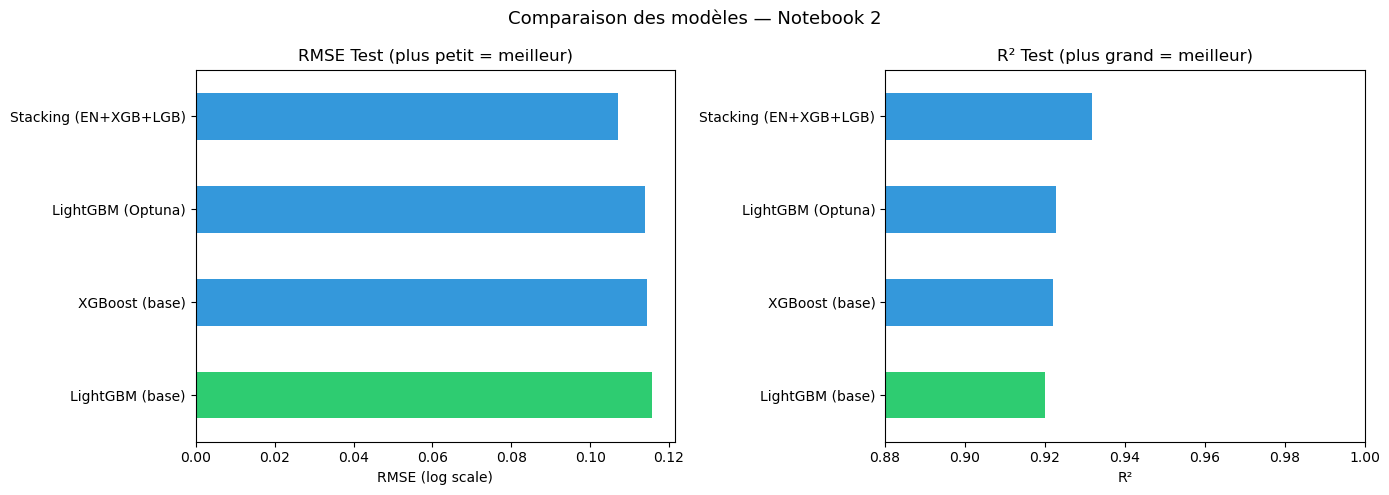

In [7]:
# ── Tableau comparatif complet
results = {
    'XGBoost (base)'       : {'RMSE CV': xgb_rmse_cv,    'RMSE Test': xgb_rmse,    'R²': xgb_r2,    'MAPE': xgb_mape},
    'LightGBM (base)'      : {'RMSE CV': lgbm_rmse_cv,   'RMSE Test': lgbm_rmse,   'R²': lgbm_r2,   'MAPE': lgbm_mape},
    'LightGBM (Optuna)'    : {'RMSE CV': study.best_value,'RMSE Test': optuna_rmse, 'R²': optuna_r2, 'MAPE': optuna_mape},
    'Stacking (EN+XGB+LGB)': {'RMSE CV': stack_rmse_cv,  'RMSE Test': stack_rmse,  'R²': stack_r2,  'MAPE': stack_mape},
}

df_results = pd.DataFrame(results).T.round(5)
df_results = df_results.sort_values('RMSE Test')

print("=" * 65)
print("  COMPARAISON FINALE — NOTEBOOK 2")
print("=" * 65)
print(df_results.to_string())

# ── Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]

df_results['RMSE Test'].plot(kind='barh', ax=axes[0], color=colors[::-1])
axes[0].set_title('RMSE Test (plus petit = meilleur)', fontsize=12)
axes[0].set_xlabel('RMSE (log scale)')
axes[0].invert_yaxis()

df_results['R²'].plot(kind='barh', ax=axes[1], color=colors[::-1])
axes[1].set_title('R² Test (plus grand = meilleur)', fontsize=12)
axes[1].set_xlabel('R²')
axes[1].set_xlim(0.88, 1.0)
axes[1].invert_yaxis()

plt.suptitle('Comparaison des modèles — Notebook 2', fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# ── Sélection automatique du meilleur modèle
best_name = df_results['RMSE Test'].idxmin()
print(f"✅ Meilleur modèle : {best_name}")

# Mapping nom → pipeline entraîné
trained_models = {
    'XGBoost (base)'       : xgb_pipeline,
    'LightGBM (base)'      : lgbm_pipeline,
    'LightGBM (Optuna)'    : best_lgbm,      # déjà fitté sur X_train_prep
    'Stacking (EN+XGB+LGB)': stacking_model,
}

# ── Feature Engineering sur df_test (identique au Notebook 1)
df_test_fe = df_test.copy()
df_test_fe['HouseAge']        = df_test_fe['YrSold'] - df_test_fe['YearBuilt']
df_test_fe['YearsSinceRemod'] = df_test_fe['YrSold'] - df_test_fe['YearRemodAdd']
df_test_fe['TotalSF']         = df_test_fe['GrLivArea'] + df_test_fe['TotalBsmtSF'].fillna(0)
df_test_fe['TotalBath']       = (df_test_fe['FullBath'] + 0.5*df_test_fe['HalfBath']
                                 + df_test_fe['BsmtFullBath'].fillna(0)
                                 + 0.5*df_test_fe['BsmtHalfBath'].fillna(0))
df_test_fe['HasPool']         = (df_test_fe['PoolArea'] > 0).astype(int)
df_test_fe['HasGarage']       = (df_test_fe['GarageArea'].fillna(0) > 0).astype(int)
df_test_fe['Has2ndFloor']     = (df_test_fe['2ndFlrSF'] > 0).astype(int)
df_test_fe['HasBsmt']         = (df_test_fe['TotalBsmtSF'].fillna(0) > 0).astype(int)

# ── Alignement des colonnes
test_cols = [c for c in X.columns if c in df_test_fe.columns]
X_kaggle  = df_test_fe[test_cols].copy()
for col in set(X.columns) - set(X_kaggle.columns):
    X_kaggle[col] = 0
X_kaggle = X_kaggle[X.columns]

# ── Prédiction avec le meilleur modèle
best_model = trained_models[best_name]

if best_name == 'LightGBM (Optuna)':
    # Ce modèle a été fitté sur X_train_prep (déjà transformé)
    X_kaggle_prep = preprocessor.transform(X_kaggle)
    log_preds = best_model.predict(X_kaggle_prep)
else:
    log_preds = best_model.predict(X_kaggle)

preds_real = np.expm1(log_preds)

print(f"Prédictions ({best_name}) :")
print(f"  Min  : {preds_real.min():,.0f} $")
print(f"  Max  : {preds_real.max():,.0f} $")
print(f"  Mean : {preds_real.mean():,.0f} $")


✅ Meilleur modèle : Stacking (EN+XGB+LGB)
Prédictions (Stacking (EN+XGB+LGB)) :
  Min  : 47,985 $
  Max  : 953,051 $
  Mean : 178,244 $


# Export 

In [10]:
# ── Export Kaggle
ids = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')['Id']

submission = pd.DataFrame({'Id': ids, 'SalePrice': preds_real})
submission.to_csv('submission_v2.csv', index=False)

print(f"✅ Fichier 'submission_v2.csv' créé — {len(submission)} prédictions")
print("\nAperçu :")
print(submission.head(10).to_string(index=False))


✅ Fichier 'submission_v2.csv' créé — 1459 prédictions

Aperçu :
  Id     SalePrice
1461 116637.977855
1462 160558.017861
1463 180531.474700
1464 196132.815986
1465 182165.999943
1466 172779.758246
1467 180891.641527
1468 165214.394388
1469 189599.858334
1470 123489.563990
